In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams["figure.figsize"] = (10, 5)

# National Grid Electricity Demand and Renewable Generation Analysis

This project uses half-hourly National Grid electricity data to explore patterns in UK energy demand during 2025. It investigates seasonal changes in demand, how temperature influences electricity usage, and how embedded wind and solar generation varies over time.

The analysis was carried out using Python, including pandas and matplotlib for data processing and visualisation.

#### Data sources:
*Electricity demand data:* Half-hourly UK electricity demand data was obtained from National Grid ESO. The dataset includes National Demand (ND), embedded wind generation, and embedded solar generation.

*Weather data:* Daily temperature observations for Glasgow were obtained from Meteostat and used to investigate the relationship between temperature and electricity demand.

## Data collection

### Electricity demand (National grid)

In [217]:
df_01 = pd.read_csv('/home/2890256a/personal/data/demanddata_2025.csv') # read the data

In [222]:
df_01.head()

,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,...,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW,TIME,TIMESTAMP
0,2025-01-01,1,21036,26215,19918,5405,6606,0,19270,0,...,1,-232,-386,-558,96,0,241,0,0 days 00:00:00,2025-01-01 00:00:00
1,2025-01-01,2,21222,26063,20167,5358,6606,0,19270,0,...,1,-124,-282,-564,51,0,262,0,0 days 00:30:00,2025-01-01 00:30:00
2,2025-01-01,3,21385,25734,20328,5237,6606,0,19270,0,...,1,-119,-384,-205,62,0,414,0,0 days 01:00:00,2025-01-01 01:00:00
3,2025-01-01,4,20473,24988,19460,5115,6606,0,19270,0,...,0,-119,-334,-193,37,0,423,0,0 days 01:30:00,2025-01-01 01:30:00
4,2025-01-01,5,19634,24912,18654,5080,6606,0,19270,0,...,0,-119,-363,-622,-282,0,288,0,0 days 02:00:00,2025-01-01 02:00:00


Relevant columns:
- SETTLEMENT_DATE - The date the historic outturn occurred.
- SETTLEMENT_PERIOD - The half hourly period for the historic outturn occurred. Settlement period 1 runs from 00:00-00:30.
- ND, National Demand (MW) - The sum of metered generation, but excludes generation required to meet station load, pump storage pumping and interconnector exports. 
- EMBEDDED_WIND_GENERATION (MW) - An estimate of the GB wind generation from wind farms which do not have Transmission System metering installed.
- EMBEDDED_SOLAR_GENERATION (MW) - An estimate of the GB solar generation from PV panels.

In [226]:
df_01.describe() # overview of averages and standard deviations

,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,...,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW,TIME,TIMESTAMP
count,17520,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.0,17520.000000,17520.000000,17520.000000,...,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520,17520
mean,2025-07-02 00:34:31.232876544,24.500228,26158.072603,28563.251256,23996.221975,1951.346233,6606.0,2130.222374,20813.171233,0.000228,...,50.336358,-254.829795,-192.334532,227.191610,1022.861130,672.369977,290.206792,-321.298345,0 days 11:45:00.410958904,2025-07-02 12:19:31.643835648
min,2025-01-01 00:00:00,1.000000,12803.000000,15297.000000,12040.000000,125.000000,6606.0,0.000000,19270.000000,0.000000,...,-1093.000000,-453.000000,-532.000000,-1024.000000,-1453.000000,-1023.000000,-1453.000000,-539.000000,0 days 00:00:00,2025-01-01 00:00:00
25%,2025-04-02 00:00:00,12.750000,21432.750000,23897.750000,19638.000000,927.000000,6606.0,0.000000,20179.000000,0.000000,...,-592.000000,-451.000000,-492.000000,-305.000000,916.000000,218.000000,-457.000000,-514.000000,0 days 05:52:30,2025-04-02 06:52:30
50%,2025-07-02 00:00:00,24.500000,24960.000000,27269.000000,22904.000000,1604.000000,6606.0,7.000000,20988.000000,0.000000,...,0.000000,-345.000000,-48.000000,348.000000,1395.000000,991.000000,461.000000,-506.000000,0 days 11:45:00,2025-07-02 12:45:00
75%,2025-10-01 00:00:00,36.250000,29825.250000,32193.250000,27386.250000,2756.000000,6606.0,3483.000000,21510.000000,0.000000,...,783.000000,-35.000000,0.000000,886.000000,1397.000000,996.000000,989.000000,-137.750000,0 days 17:37:30,2025-10-01 18:37:30
max,2025-12-31 00:00:00,50.000000,45924.000000,47760.000000,41835.000000,5922.000000,6606.0,14046.000000,22126.000000,2.000000,...,1116.000000,400.000000,504.000000,1063.000000,1491.000000,1063.000000,1428.000000,506.000000,1 days 00:30:00,2025-12-31 23:30:00
std,NaN,13.854190,6172.933513,6107.866569,5650.814832,1279.663725,0.0,3281.983315,840.120108,0.021368,...,723.071698,219.912302,237.632607,676.693354,636.782911,440.439194,854.485430,280.515292,0 days 06:55:37.542023451,NaN


In [219]:
# convert SETTLEMENT_DATE from 'object' to 'datetime'

df_01["SETTLEMENT_DATE"] = pd.to_datetime(df_01["SETTLEMENT_DATE"])

In [220]:
df_01["TIME"] = pd.to_timedelta((df_01["SETTLEMENT_PERIOD"] - 1) * 30, unit="min") # convert periods into minutes

In [221]:
df_01["TIMESTAMP"] = df_01["SETTLEMENT_DATE"] + df_01["TIME"] # create timestamps
df_01["TIMESTAMP"] = pd.to_datetime(df_01["TIMESTAMP"])

The data is now ready to plot.

### Temperature (Meteostat)

In [223]:
df_02 = pd.read_csv('/home/2890256a/personal/data/glasgowweather_2025.csv') # read the data

In [224]:
df_02.head()

,date,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun
0,2025-01-01 00:00:00,4.0,-3,8,1.8,NaN,NaN,16.2,57.4,1001.5,11
1,2025-01-02 00:00:00,-1.8,-4,3,0.0,NaN,NaN,9.2,22.2,1020.3,251
2,2025-01-03 00:00:00,1.2,-1,5,0.3,NaN,NaN,8.6,31.5,1019.6,186
3,2025-01-04 00:00:00,0.6,-1,3,0.5,NaN,NaN,5.3,20.4,1011.0,12
4,2025-01-05 00:00:00,1.2,-1,3,0.1,NaN,NaN,10.1,24.1,992.9,14


In [227]:
# convert date from 'object' to 'datetime'

df_02["date"] = pd.to_datetime(df_02["date"])

## Data analysis

### Yearly electricity demand

Predictions:
- More electricity usage during extreme temperatures (heating in Winter, air conditioning in Summer)

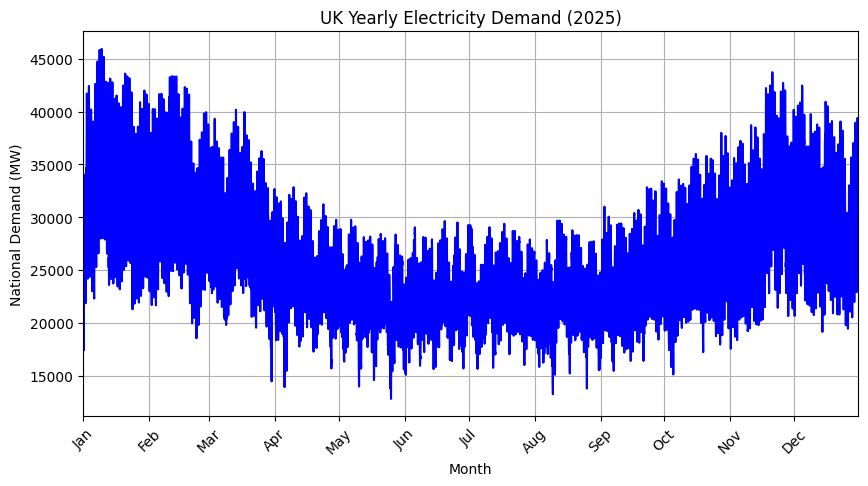

In [156]:
df_01_plot = df_01.set_index("TIMESTAMP") # use timestamp as index

plt.plot(df_01_plot.index, df_01_plot["ND"], color = 'blue')

plt.xlim(pd.Timestamp("2025-01-01"), pd.Timestamp("2025-12-31"))

plt.gca().xaxis.set_major_locator(mdates.MonthLocator()) 
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b")) # change format of xaxis to display month name

plt.title('UK Yearly Electricity Demand (2025)')
plt.xlabel('Month')
plt.ylabel('National Demand (MW)')

plt.xticks(rotation=45)
plt.grid()
plt.show()

Analysis:

- The National demand is seasonal as predicted with peaks in the Winter months due to the need for heating.
- Electricity usage decreases with steadily rising temperatures in Spring and increases across Autumn as temperatures decrease.
- The pattern displays a slight peak in Summer where the hottest months may require air conditioning.

### How does electricity demand change with temperature?

In [228]:
daily_demand = df_01_plot["ND"].resample("D").mean() # find daily mean for 365 points

In [229]:
x = df_02_plot["tavg"]
y = daily_demand

In [230]:
m, b = np.polyfit(x, y, 1) # fit a straight line

In [231]:
linear_fit = m*x + b

Linear regression coefficient: -708 MW/°C


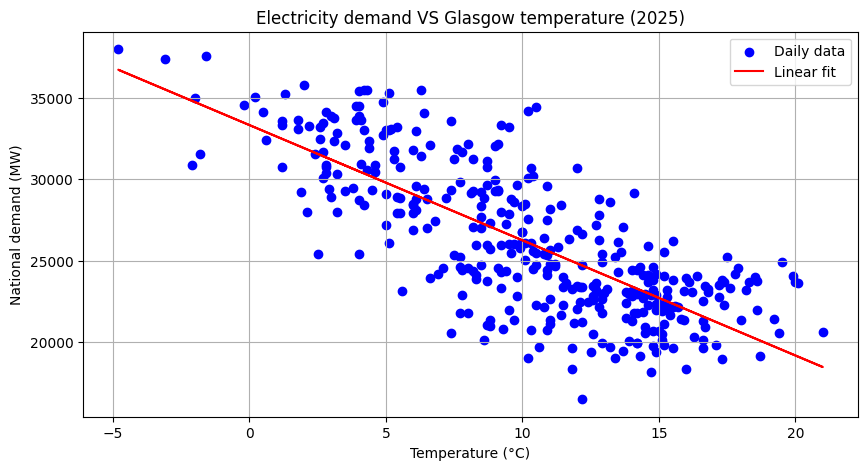

In [233]:
plt.scatter(df_02_plot["tavg"], daily_demand, color = 'blue', label = 'Daily data')

plt.plot(x, linear_fit, color = 'red', label = 'Linear fit')

plt.title('Electricity demand VS Glasgow temperature (2025)')
plt.xlabel('Temperature (°C)')
plt.ylabel('National demand (MW)')

print(f"Linear regression coefficient: {m:.3g} MW/°C")

plt.grid()
plt.legend()

plt.show()

The negative regression coefficient indiciates the average electricity demand increases as temperature decreases. This aligns with the predictions and analysis of the yearly electricity demand.

### Renewable electricity generation patterns

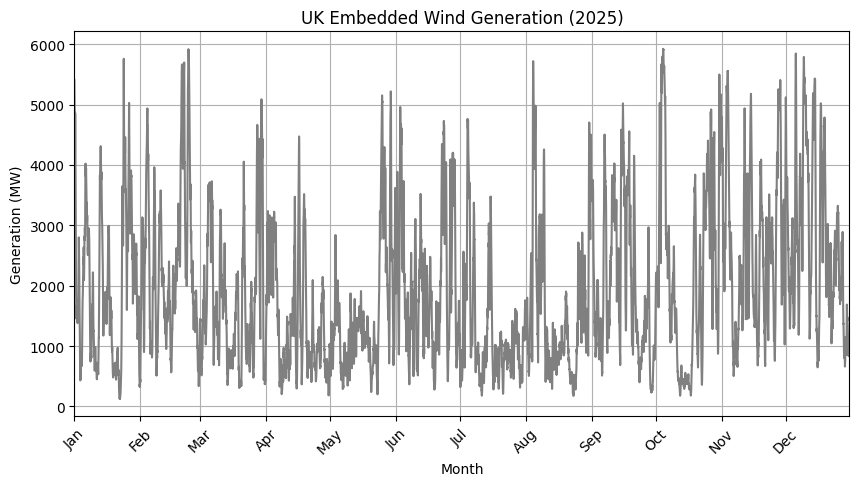

In [163]:
plt.plot(df_01_plot.index, df_01_plot["EMBEDDED_WIND_GENERATION"], label="Embedded Wind", color = 'grey')

plt.xlim(pd.Timestamp("2025-01-01"), pd.Timestamp("2025-12-31"))

plt.gca().xaxis.set_major_locator(mdates.MonthLocator()) 
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b")) # change format of xaxis to display month name

plt.xlabel("Month")
plt.ylabel("Generation (MW)")
plt.title("UK Embedded Wind Generation (2025)")

plt.xticks(rotation=45)
plt.grid()
plt.show()

The relationship between wind generation and time of year appears to be irregular with large fluctuations, with a slight increase in wind during colder Winter months.

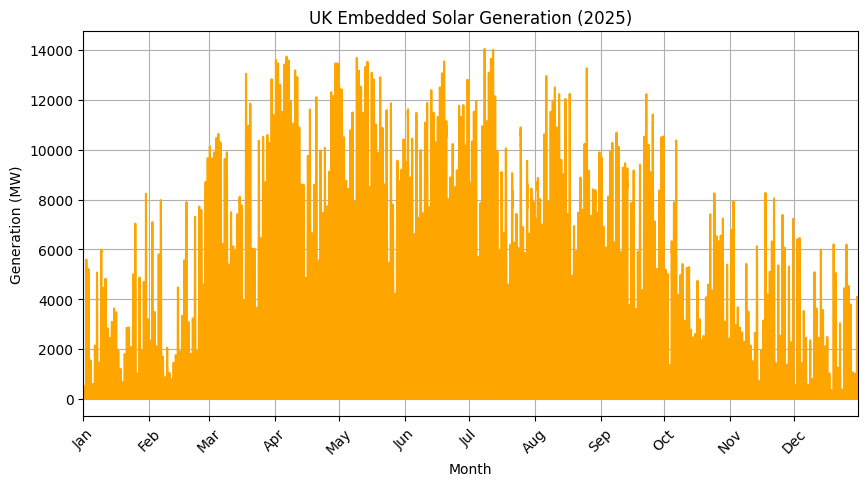

In [202]:
plt.plot(df_01_plot.index, df_01_plot["EMBEDDED_SOLAR_GENERATION"], label="Embedded Solar", color = 'orange')

plt.xlim(pd.Timestamp("2025-01-01"), pd.Timestamp("2025-12-31"))

plt.gca().xaxis.set_major_locator(mdates.MonthLocator()) 
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b")) # change format of xaxis to display month name

plt.xlabel("Month")
plt.ylabel("Generation (MW)")
plt.title("UK Embedded Solar Generation (2025)")

plt.xticks(rotation=45)
plt.grid()
plt.show()

Solar electricity generation across the year is as expected with more electricity being generated during typical "sunnier" months. There is a notable drop in generation during Winter.

### Renwable electricity generation relative to demand

In [234]:
df_01_plot["EMBEDDED_RENEWABLES"] = df_01_plot["EMBEDDED_WIND_GENERATION"] + df_01_plot["EMBEDDED_SOLAR_GENERATION"]

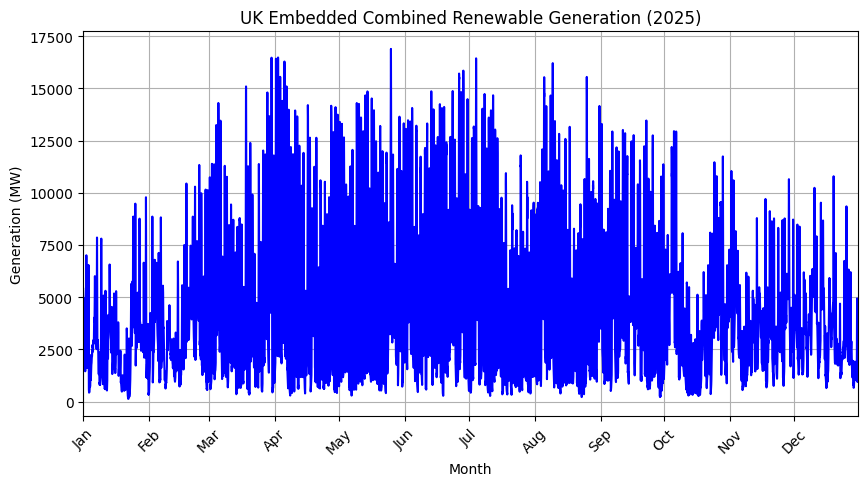

In [235]:
plt.plot(df_01_plot.index, df_01_plot["EMBEDDED_RENEWABLES"], color = 'blue')

plt.xlim(pd.Timestamp("2025-01-01"), pd.Timestamp("2025-12-31"))

plt.gca().xaxis.set_major_locator(mdates.MonthLocator()) 
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b")) # change format of xaxis to display month name

plt.xlabel("Month")
plt.ylabel("Generation (MW)")
plt.title("UK Embedded Combined Renewable Generation (2025)")

plt.xticks(rotation=45)
plt.grid()
plt.show()

In [236]:
df_01_plot["RENEWABLE_RATIO"] = df_01_plot["EMBEDDED_RENEWABLES"] / df_01_plot["ND"]

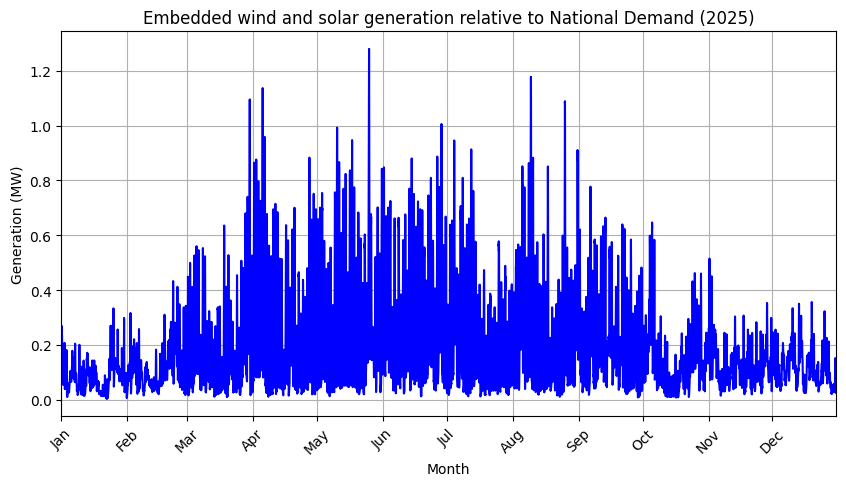

In [237]:
plt.plot(df_01_plot.index, df_01_plot["RENEWABLE_RATIO"], color = 'blue')

plt.xlim(pd.Timestamp("2025-01-01"), pd.Timestamp("2025-12-31"))

plt.gca().xaxis.set_major_locator(mdates.MonthLocator()) 
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b")) # change format of xaxis to display month name

plt.xlabel("Month")
plt.ylabel("Generation (MW)")
plt.title("Embedded wind and solar generation relative to National Demand (2025)")

plt.xticks(rotation=45)
plt.grid()
plt.show()

The embedded wind and solar generation occasionally exceeded 100% of the national demand, with a peak of ~130%, however the embedded renewable generation is only an estimate and the national demand excludes generation required to meet station load, pump storage pumping and interconnector exports. 

## Analysis of extreme grid conditions

### Monthly renewable generation and demand

In [197]:
monthly_summary = df_plot.resample("ME").mean() # group data into months and calculate average

In [198]:
monthly_summary["TOTAL_EMBEDDED_RENEWABLES"] = (monthly_summary["EMBEDDED_WIND_GENERATION"] + monthly_summary["EMBEDDED_SOLAR_GENERATION"])

In [199]:
monthly_summary[
    ["ND", "EMBEDDED_WIND_GENERATION", "EMBEDDED_SOLAR_GENERATION", "TOTAL_EMBEDDED_RENEWABLES"]
]

,ND,EMBEDDED_WIND_GENERATION,EMBEDDED_SOLAR_GENERATION,TOTAL_EMBEDDED_RENEWABLES
TIMESTAMP,,,,
2025-01-31,33302.827285,2001.250672,623.363575,2624.614247
2025-02-28,31677.455357,2406.096726,954.082589,3360.179315
2025-03-31,27456.175639,1738.715343,2382.788022,4121.503365
2025-04-30,23599.828472,1414.312500,3320.878472,4735.190972
2025-05-31,21706.562500,1510.091398,3585.339382,5095.430780
2025-06-30,21847.457639,2002.455556,3597.854167,5600.309722
2025-07-31,22665.625000,1188.024194,3179.936156,4367.960349
2025-08-31,21808.459005,1581.700269,2958.754704,4540.454973
2025-09-30,23629.193750,2037.978472,2373.306944,4411.285417


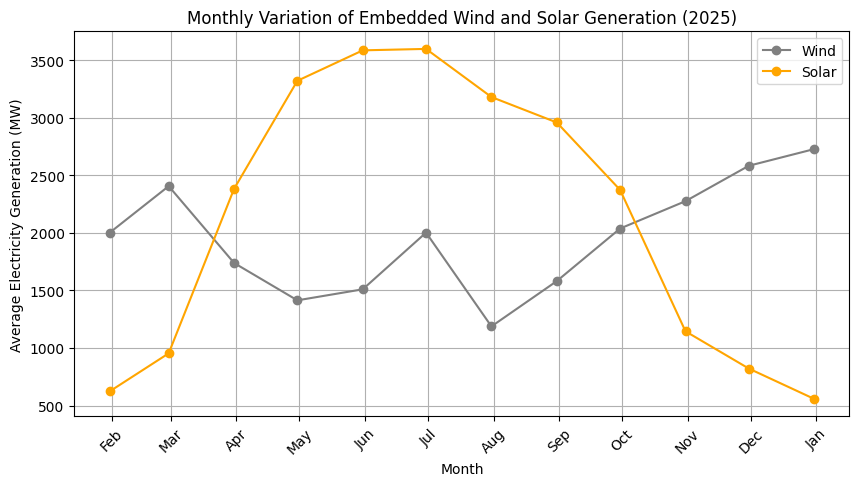

In [210]:
plt.plot(monthly_summary.index, monthly_summary["EMBEDDED_WIND_GENERATION"], color = 'grey', label = 'Wind', marker = 'o')
plt.plot(monthly_summary.index, monthly_summary["EMBEDDED_SOLAR_GENERATION"], color = 'orange', label = 'Solar', marker = 'o')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator()) 
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b")) # change format of xaxis to display month name

plt.title('Monthly Variation of Embedded Wind and Solar Generation (2025)')
plt.xlabel('Month')
plt.ylabel('Average Electricity Generation (MW)')

plt.xticks(rotation=45)
plt.legend()
plt.grid()

plt.show()

The above graph shows the embedded solar generation peak in Summer, with increased embedded wind generation in Winter.

### Highest demand periods

In [240]:
df_plot.nlargest(10, "ND")[["ND"]] # find top 10 peak demand periods

,ND
TIMESTAMP,
2025-01-09 17:00:00,45924
2025-01-09 17:30:00,45881
2025-01-08 17:30:00,45823
2025-01-08 17:00:00,45769
2025-01-08 18:00:00,45472
2025-01-09 18:00:00,45444
2025-01-09 16:30:00,45436
2025-01-08 16:30:00,45405
2025-01-09 18:30:00,45367


Electricity demand peaks occur between 16:30 and 18:30 indicating increased activity in households at this time. This aligns with people returning home from work and using electricity for cooking, lighting and heating. Additionally, the top 10 highest demand periods are all in January due to the increased need for heating during the cold month. This agrees with the observed inverse relationship between temperature and demand.

In [215]:
highest_demand = df_plot.nlargest(10, "ND")

highest_demand[
    ["ND", "EMBEDDED_WIND_GENERATION", "EMBEDDED_SOLAR_GENERATION"]
]

,ND,EMBEDDED_WIND_GENERATION,EMBEDDED_SOLAR_GENERATION
TIMESTAMP,,,
2025-01-09 17:00:00,45924,2217,0
2025-01-09 17:30:00,45881,2212,0
2025-01-08 17:30:00,45823,884,0
2025-01-08 17:00:00,45769,850,0
2025-01-08 18:00:00,45472,879,0
2025-01-09 18:00:00,45444,2079,0
2025-01-09 16:30:00,45436,2221,0
2025-01-08 16:30:00,45405,816,0
2025-01-09 18:30:00,45367,1945,0


Periods of high electricity demand were not supported by any embedded solar generation and associated with little embedded wind generation. This high demand and low wind/solar generation combination can increase pressure on the electricity system, as additional electricity sources may be required to meet the demand.

This highlights the challenge of balancing high electricity demand with variable renewable generation, where wind and solar output can change significantly depending on weather conditions.